# Bio Weavers MVP — Demo Notebook

Quick walkthrough of the proof-of-life pipeline.

In [12]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
#import contextily as ctx

# Ensure repo root is on sys.path
repo_root = Path.cwd().resolve()
if (repo_root / 'src').exists():
    sys.path.insert(0, str(repo_root))
elif (repo_root.parent / 'src').exists():
    sys.path.insert(0, str(repo_root.parent))


In [13]:
from pathlib import Path

from src.geometry import load_boundary, create_buffer, get_bounding_box, load_all_quads, get_quads, get_species_cnps, get_species_cnddb, get_neighbors
from src.species import refactor_cnps, plot_cnddb_species_distribution, plot_cnddb_species_date_range, plot_species_map # get_unique_species, filter_federally_listed
# from src.export import export_species_csv, export_species_excel


<Axes: >

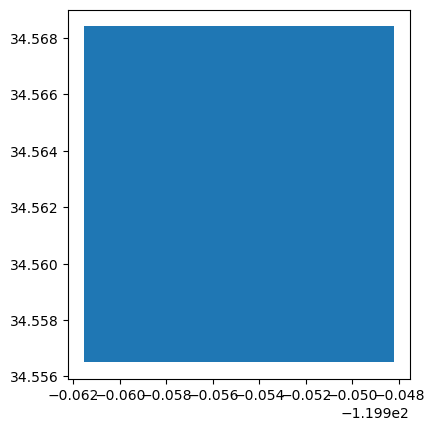

In [14]:
# Load sample boundary.
boundary_path = Path("../data/lake_cachuma.geojson")
boundary = load_boundary(boundary_path)
boundary.plot()

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# load your data
gdf = gpd.read_file("../data/lake_cachuma.geojson")

# load quadrangles
quads = gpd.read_file("../data/california_statewide_index_of_usgs_24k_7_5_minute_quad_topo_maps.geojson")

# IMPORTANT: convert to web mercator
gdf = gdf.to_crs(epsg=3857)
quads = quads.to_crs(epsg=3857)

# plot quadrangles first
ax = quads.plot(figsize=(8, 8),
                facecolor="none",
                edgecolor="blue",
                linewidth=0.5)

# plot boundary on top
boundary.plot(ax=ax,
              facecolor="none",
              edgecolor="red",
              linewidth=2)

xmin, ymin, xmax, ymax = gdf.total_bounds

# adjust this value to control zoom
zoom_factor = 5  # 20% extra space

xpad = (xmax - xmin) * zoom_factor
ypad = (ymax - ymin) * zoom_factor

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# add basemap
ctx.add_basemap(ax)

plt.show()

In [15]:
# Create a mile based buffer and bounding box.
buffered_2mi_boundary = create_buffer(boundary, distance=4828.03) # 2-miles in meters
bbox = get_bounding_box(buffered_2mi_boundary)
bbox

array([-120.01417812,   34.51299948, -119.89555352,   34.61190224])

In [16]:
# Load in all quads in California.
all_quads_path = Path("../data/california_statewide_index_of_usgs_24k_7_5_minute_quad_topo_maps.geojson")
all_quads = load_all_quads(all_quads_path)

In [17]:
# Get the list of quads that intersect with the boundary.
quad_ids = get_quads(buffered_2mi_boundary, all_quads)
quad_ids

{3411958, 3412051}

In [ ]:
# 9-quad buffer search.
buffer_quad_search = get_neighbors(quad_ids, all_quads)
buffer_quad_search

In [ ]:
# Refactor CNPS Quad list.
cnps_path = Path("../data/CNPS_RAW.csv")
cnps = refactor_cnps(cnps_path)

In [ ]:
# Get the CNPS species that are found within the intersecting quads.
cnps_species = get_species_cnps(cnps, quad_ids)
cnps_species.head()

In [18]:
# Get the CNDBB species that are found within the intersecting quads.
cnddb_path = Path("../data/cnddb_obfs_dataset_V2.csv")
cnddb_species = get_species_cnddb(cnddb_path, quad_ids)
cnddb_species

,OBJECTID,SNAME,CNAME,ELMCODE,OCCNUMBER,MAPNDX,EONDX,KEYQUAD,KQUADNAME,KEYCOUNTY,...,THREAT,THREATLIST,LASTUPDATE,AREA,PERIMETER,AVLCODE,Symbology,BUFF_DIST,Shape_Length,Shape_Area


In [ ]:
# Plot the distribution of CNDBB species occurrences.
species_distribution_plot = plot_cnddb_species_distribution(cnddb_species)
species_distribution_plot.show()

In [ ]:
# Plot the date range of CNDBB species occurrences.
species_date_range_plot = plot_cnddb_species_date_range(cnddb_species)

In [ ]:
plot_species_map(cnddb_species, buffered_2mi_boundary)

In [ ]:
# # Build species list + filter federally listed
# species = get_unique_species(observations)
# listed = filter_federally_listed(species)
# species.head()

In [ ]:
# # Export outputs
# output_dir = Path("../output")
# export_species_csv(species, output_dir / "species.csv", project_name="Sample Project")
# export_species_excel(species, listed, output_dir / "species.xlsx", project_name="Sample Project")
